In [75]:
import uproot
import pandas as pd
import numpy as np
import glob


In [76]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [77]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250122"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg"
tree_name = "Ks"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [78]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [79]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,709084.000000,709084.000000,709084.000000,709084.000000,709084.000000
mean,1.813516,0.179600,0.395490,1.587180,-0.005633
std,0.106080,0.499894,0.475806,0.862431,0.999985
min,1.600000,-0.999950,-0.904490,0.400002,-1.000000
25%,1.717484,-0.225839,0.055094,0.870955,-1.000000
50%,1.866106,0.244465,0.524824,1.442380,-1.000000
75%,1.872934,0.608380,0.809122,2.145434,1.000000
max,2.100000,0.999993,0.977563,5.330872,1.000000


In [80]:
df_proc13 = df_proc13.query('Dp_M> 1.80 & Dp_M<1.93')


In [81]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,421470.000000,421470.000000,421470.000000,421470.000000,421470.000000
mean,1.868664,0.161556,0.365183,1.699724,-0.006511
std,0.016083,0.502327,0.473395,0.885750,0.999980
min,1.800002,-0.998423,-0.890731,0.400003,-1.000000
25%,1.865657,-0.249723,0.013755,0.970101,-1.000000
50%,1.869961,0.218498,0.476412,1.585274,-1.000000
75%,1.874158,0.593496,0.781541,2.271983,1.000000
max,1.929997,0.999993,0.976929,5.330872,1.000000


In [82]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [87]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250122"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg"
tree_name = "Ks"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [88]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [89]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,2.719136e+06,2.719136e+06,2.719136e+06,2.719136e+06,2.719136e+06
mean,1.803000e+00,1.674453e-01,3.886917e-01,1.534526e+00,-1.358520e-03
std,1.101250e-01,4.957589e-01,4.730843e-01,8.377187e-01,9.999993e-01
min,1.600000e+00,-9.992926e-01,-9.075612e-01,4.000020e-01,-1.000000e+00
25%,1.693608e+00,-2.353433e-01,5.100285e-02,8.482077e-01,-1.000000e+00
50%,1.864189e+00,2.239842e-01,5.130564e-01,1.370830e+00,-1.000000e+00
75%,1.871833e+00,5.920096e-01,7.976846e-01,2.067037e+00,1.000000e+00
max,2.099999e+00,9.999999e-01,9.779149e-01,5.422326e+00,1.000000e+00


In [90]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.80 & Dp_M<1.93')


In [91]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.481941e+06,1.481941e+06,1.481941e+06,1.481941e+06,1.481941e+06
mean,1.867885e+00,1.483541e-01,3.596470e-01,1.678590e+00,-8.414640e-04
std,1.640187e-02,5.000249e-01,4.718335e-01,8.721717e-01,1.000000e+00
min,1.800001e+00,-9.992926e-01,-9.075612e-01,4.000020e-01,-1.000000e+00
25%,1.865460e+00,-2.626195e-01,1.003197e-02,9.638901e-01,-1.000000e+00
50%,1.869578e+00,1.971935e-01,4.678963e-01,1.560166e+00,-1.000000e+00
75%,1.873261e+00,5.773996e-01,7.720243e-01,2.240154e+00,1.000000e+00
max,1.930000e+00,9.999999e-01,9.771120e-01,5.422326e+00,1.000000e+00


In [92]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [93]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [94]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


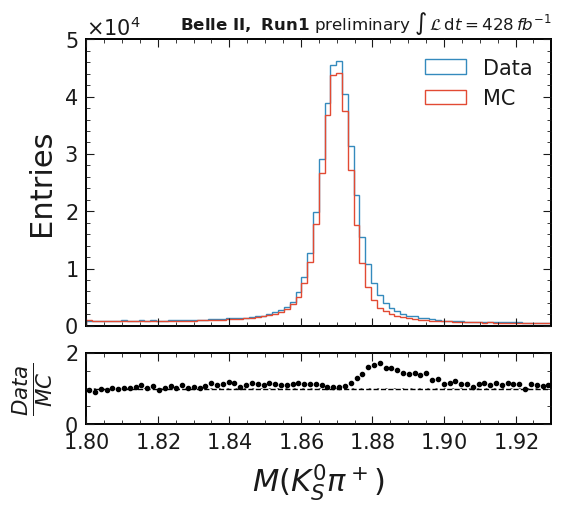

In [96]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.80,1.93)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}.png", bbox_inches="tight")